# Neural Network

Xây dựng neural network với hai tầng ẩn (hidden layer).
Các trọng số và mối liên hệ giữa các tầng ẩn được thiết lập
và cài đặt bằng tay.

## Neural Network Overview

<img src="http://cs231n.github.io/assets/nn1/neural_net2.jpeg" alt="nn" style="width: 400px;"/>

## MNIST Dataset Overview

MNIST là bộ dữ liệu chứa các ảnh là các ký tự viết tay, chia thành 2 phần, 60000 ảnh dùng để huấn luyện và 10000 ảnh dùng để kiểm thử. Kích thước các ảnh là 28x28, giá trị các pixel thuộc [0,255]


![MNIST Dataset](http://neuralnetworksanddeeplearning.com/images/mnist_100_digits.png)

More info: http://yann.lecun.com/exdb/mnist/

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
# MNIST dataset parameters.
num_classes = 10 # total classes (0-9 digits).
num_features = 784 # data features (img shape: 28*28).

# Network parameters.
n_hidden_1 = 128 # 1st layer number of neurons.
# n_hidden_2 = 256 # 2nd layer number of neurons.

In [ ]:
# Chuẩn bị dữ liệu
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Chuyển đổi sang định dạng float32.
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)
x_train, x_test = x_train.reshape([-1, num_features]).T, x_test.reshape([-1, num_features]).T
# Chuẩn hóa ảnh từ [0, 255] to [0, 1].
x_train, x_test = x_train / 255., x_test / 255.

In [ ]:
m = x_train.shape[1]

In [ ]:
def cross_entropy(predictions, targets, epsilon=1e-12):
    """
    Computes cross entropy between targets (encoded as one-hot vectors)
    and predictions.
    Input: predictions (N, k) ndarray
           targets (N, k) ndarray
    Returns: scalar
    """
    predictions = np.clip(predictions, epsilon, 1. - epsilon)
    N = predictions.shape[0]
    ce = -np.sum(targets*np.log(predictions+1e-9))/N
    return ce

In [ ]:
def init_params():
    # W1: (128, 784), b1: (128, 1), W2: (10, 128), b2: (10, 1)
    W1 = np.random.rand(n_hidden_1, 784) - 0.5
    b1 = np.random.rand(n_hidden_1, 1) - 0.5
    W2 = np.random.rand(num_classes, n_hidden_1) - 0.5
    b2 = np.random.rand(num_classes, 1) - 0.5
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True)) # added stability
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def cross_entropy(predictions, targets, epsilon=1e-12):
    # targets: one_hot_Y (10, m), predictions: A2 (10, m)
    predictions = np.clip(predictions, epsilon, 1. - epsilon)
    N = predictions.shape[1]
    ce = -np.sum(targets * np.log(predictions)) / N
    return ce

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def ReLU_deriv(Z):
    return Z > 0

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, 10))
    one_hot_Y[np.arange(Y.size), Y.astype(int)] = 1
    return one_hot_Y.T

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m_samples = X.shape[1]
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m_samples * dZ2.dot(A1.T)
    db2 = 1 / m_samples * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m_samples * dZ1.dot(X.T)
    db1 = 1 / m_samples * np.sum(dZ1, axis=1, keepdims=True)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [ ]:
losses = []
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    one_hot_Y = one_hot(Y)
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)

        if i % 10 == 0:
            predictions = get_predictions(A2)
            current_loss = cross_entropy(A2, one_hot_Y)
            losses.append(current_loss)
            print(f'Iteration: {i}, Loss: {current_loss:.4f}, Accuracy: {get_accuracy(predictions, Y):.3f}')
    return W1, b1, W2, b2

In [ ]:
alpha = 0.15
n_epoch = 200
W1, b1, W2, b2 = gradient_descent(x_train, y_train, alpha, n_epoch)

Iteration: 0, Loss: 58852.0484, Accuracy: 0.113
Iteration: 10, Loss: 9979.8795, Accuracy: 0.554
Iteration: 20, Loss: 6479.9178, Accuracy: 0.689
Iteration: 30, Loss: 5222.1157, Accuracy: 0.749
Iteration: 40, Loss: 4571.5286, Accuracy: 0.778
Iteration: 50, Loss: 4142.5108, Accuracy: 0.798
Iteration: 60, Loss: 3830.9341, Accuracy: 0.813
Iteration: 70, Loss: 3590.8339, Accuracy: 0.824
Iteration: 80, Loss: 3398.1191, Accuracy: 0.833
Iteration: 90, Loss: 3238.7808, Accuracy: 0.841
Iteration: 100, Loss: 3103.6350, Accuracy: 0.847
Iteration: 110, Loss: 2986.9508, Accuracy: 0.852
Iteration: 120, Loss: 2884.8974, Accuracy: 0.857
Iteration: 130, Loss: 2794.5979, Accuracy: 0.862
Iteration: 140, Loss: 2714.0500, Accuracy: 0.866
Iteration: 150, Loss: 2641.5300, Accuracy: 0.869
Iteration: 160, Loss: 2575.7983, Accuracy: 0.873
Iteration: 170, Loss: 2515.9422, Accuracy: 0.876
Iteration: 180, Loss: 2461.0494, Accuracy: 0.878
Iteration: 190, Loss: 2410.4073, Accuracy: 0.881


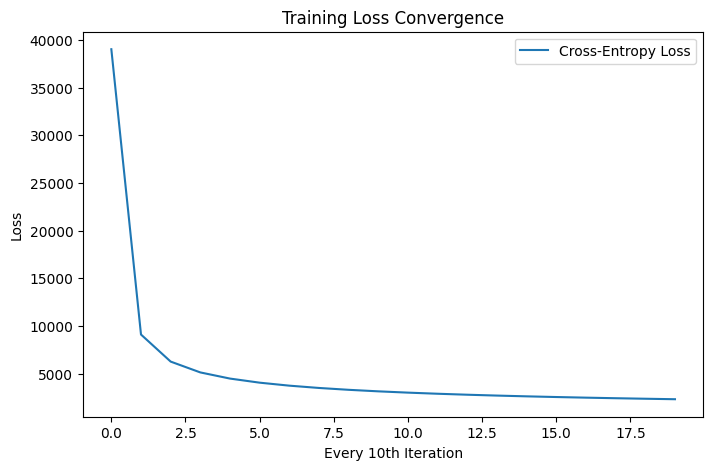

In [ ]:
# Biểu đồ biểu diễn độ biến thiên của hàm mất mát qua các vòng lặp
plt.figure(figsize=(8,5))
plt.plot(range(len(losses)), losses, label='Cross-Entropy Loss')
plt.xlabel('Every 10th Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Convergence')
plt.legend()
plt.show()